In [5]:
%load_ext autoreload
%autoreload 2
import torch 
from torch import nn
import torchvision
from torchvision import transforms
from torchvision.transforms import v2
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
from physics_utils import *
from dataset import *
import yaml
from torch.utils.data import WeightedRandomSampler
from torchvision import models
from torch.cuda.amp import GradScaler, autocast
import yaml
from tqdm import tqdm
from model import *



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
config_path = '../src/config.yaml'
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

In [ ]:
temp_train_ds=DatasetMaker(config['data_path']['train'],transforms=transforms.Compose([FftTransform(width=config['fft_params']['notch_width'], depth=config['fft_params']['notch_depth'],
                                                    apply_bilateral=config['fft_params']['apply_bilateral'],dual_channel=config['fft_params']['dual_channel']),
                                   transforms.ToTensor()]), project_root=Path.cwd().parent)
all=[temp_train_ds[i][0] for i in range(len(temp_train_ds))]
a=torch.stack(all,dim=0)
train_fft_mean=a[:,1,:,:].mean().item()
train_fft_std=a[:,1,:,:].std().item()  ## add these stats to the config file for further use
train_original_mean=a[:,0,:,:].mean().item()
train_original_std=a[:,0,:,:].std().item()

In [ ]:
config['stats']['train_fft_mean'] = round(train_fft_mean, 4)
config['stats']['train_fft_std'] = round(train_fft_std, 4)
config['stats']['train_original_std'] = round(train_original_std, 4)
config['stats']['train_original_mean'] = round(train_original_mean, 4)
counts_dict = config['train_class_count']
counts = torch.tensor([counts_dict[i] for i in range(len(counts_dict))], dtype=torch.float32)
class_weights = 1.0 / counts
print(f"Calculated Weights: {class_weights}")
config['class_weight']=class_weights.tolist()
config['batch_size']=32
with open(config_path, 'w') as f:
    yaml.dump(config, f, default_flow_style=False)
print("YAML updated")

Calculated Weights: tensor([0.0008, 0.0042, 0.0118, 0.0017])
YAML updated


In [ ]:
train_transform = transforms.Compose([FftTransform(width=config['fft_params']['notch_width'], depth=config['fft_params']['notch_depth'],
                                                   apply_bilateral=config['fft_params']['apply_bilateral']),
                                      transforms.RandomHorizontalFlip(p=0.5),
                                      transforms.RandomVerticalFlip(p=0.5),
                    # rotations (90 deg increase) to not destroy the fft transform
                                      transforms.RandomChoice([
                                      transforms.RandomRotation((0, 0)),
                                      transforms.RandomRotation((90, 90)),
                                      transforms.RandomRotation((180, 180)),
                                      transforms.RandomRotation((270, 270))]),
                                      transforms.ToTensor(),
                                      transforms.Normalize(mean=[config['stats']['train_original_mean'],config['stats']['train_fft_mean']],
                                                           std=[config['stats']['train_original_std'],config['stats']['train_fft_std']])])

val_transform =transforms.Compose([FftTransform(width=config['fft_params']['notch_width'], depth=config['fft_params']['notch_depth'],
                                                    apply_bilateral=config['fft_params']['apply_bilateral']),
                                   transforms.ToTensor(),
                                   transforms.Normalize(mean=[config['stats']['train_original_mean'],config['stats']['train_fft_mean']],
                                                           std=[config['stats']['train_original_std'],config['stats']['train_fft_std']])])

In [12]:
train_transform2 = transforms.Compose([
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomVerticalFlip(p=0.5),
    v2.RandomChoice([
        v2.RandomRotation((0, 0)),
        v2.RandomRotation((90, 90)),
        v2.RandomRotation((180, 180)),
        v2.RandomRotation((270, 270))
    ]),
    v2.ElasticTransform(alpha=50.0, sigma=5.0), 
    FftTransform(
        width=config['fft_params']['notch_width'], 
        depth=config['fft_params']['notch_depth'],
        apply_bilateral=config['fft_params']['apply_bilateral'],
        dual_channel=config['fft_params']['dual_channel'] 
    ),
    v2.ColorJitter(brightness=0.1, contrast=0.1),
    v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)]),
    v2.Normalize(
        mean=[config['stats']['train_original_mean'], config['stats']['train_fft_mean']],
        std=[config['stats']['train_original_std'], config['stats']['train_fft_std']])])

In [14]:
train_ds=DatasetMaker(data_csv_path=config['data_path']['train'],transforms=train_transform2,project_root=Path.cwd().parent)
#val_ds=DatasetMaker(data_csv_path=config['data_path']['val'],transforms=val_transform,project_root=Path.cwd().parent)
#test_ds=DatasetMaker(data_csv_path=config['data_path']['test'],transforms=val_transform,project_root=Path.cwd().parent)

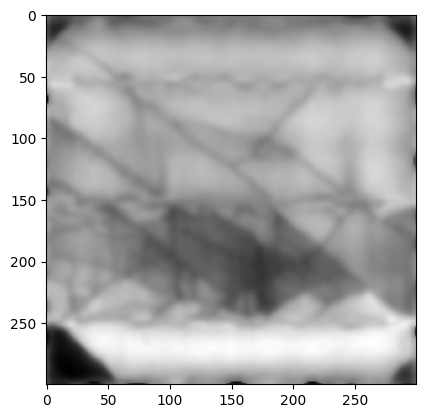

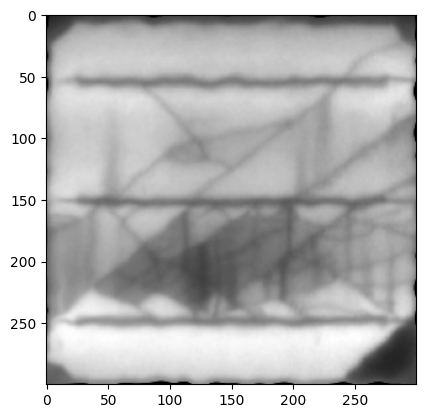

In [33]:
plt.imshow(train_ds[1245][0][1,:,:].squeeze(),cmap='gray')
plt.show()
plt.imshow(train_ds[1245][0][0,:,:].squeeze(),cmap='gray')

**we weight each image label so that we fix the imbalanced labels issue in the dataset where we have majority call of label 0**

In [ ]:
train_dl=DataLoader(train_ds,batch_size=config['batch_size'],sampler=sampler)
test_dl=DataLoader(test_ds,batch_size=config['batch_size'])
val_dl=DataLoader(val_ds,batch_size=config['batch_size'])

In [ ]:
model=PhotonicResNet50().to(device=device)

**lets check the output dimensions before we start training**

In [ ]:
test_input = torch.randn(1, 1, 224, 224).to(device)
with torch.no_grad():
    output = model(test_input)

print(f"Input Shape: {test_input.shape}")
print(f"Output Shape: {output.shape}") 

Input Shape: torch.Size([1, 1, 224, 224])
Output Shape: torch.Size([1, 4])


**we will utilize mixed precesion for faster performance since i am running it on my local gpu**

In [ ]:
def get_global_stats(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    all_probabilities = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            probs=F.softmax(outputs, dim=1)
            #convert to numpy for sklearn metrics to use
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probabilities.extend(probs.cpu().numpy())
    return all_labels, all_preds, all_probabilities
